In [1]:
# Importation des packages

# Standard library imports
import os

# Third-party library imports
import joblib
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

# Scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Other machine learning library imports
from xgboost import XGBRegressor

# Statsmodels and Scipy imports for statistical tests
from scipy.stats import shapiro
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

### **Importation**

In [ ]:

# Télécharger le dataset
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Chemin du dossier :", path)

# Lister les fichiers
files = os.listdir(path)
print("Fichiers disponibles :", files)

# Charger le CSV
csv_path = os.path.join(path, "insurance.csv")
data = pd.read_csv(csv_path)

# Afficher les 10 premières lignes
display(data.head(10))


Using Colab cache for faster access to the 'insurance' dataset.
Chemin du dossier : /kaggle/input/insurance
Fichiers disponibles : ['insurance.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
display(data.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### **Preprocessing**

In [ ]:
# Définition des groupes de colonnes
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']

In [ ]:
# Création des "sous-pipelines" de traitement
# Pipeline pour les chiffres : Mise à l'échelle
num_transformer = Pipeline(steps=[
    ('scaler', 'passthrough') #Definir le scaler et ne rien faire(laisser passer)
])

# Pipeline pour les catégories : Encodage
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # ignore gère les nouvelles catégories
])

# Assemblage du Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])


### **Séparation des données**

In [ ]:
## Séparation en variables explicatives et variable cible
X = data.drop('charges', axis=1)
y = data['charges']

## Séparation en donnée d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### **Modélisation**

In [ ]:
# On définit les scalers à tester pour les modèles sensibles
scalers = {
        'None': 'passthrough',
        'Standard': StandardScaler(),
        'MinMax': MinMaxScaler(),
        'Robust': RobustScaler(),
        'MaxAbs': MaxAbsScaler()
    }

# Modèles nécessitant impérativement un scaling (Linéaires régularisés)
scaling_models = {
        'Lasso': Lasso(),
        'Ridge': Ridge(),
        'ElasticNet': ElasticNet(),
        'KNN': KNeighborsRegressor(),
        'SVR': SVR()
    }

# Modèles robustes au scaling (Basés sur les arbres)
no_scaling_models = {
        'reg_lin': LinearRegression(),
        'DecisionTree': DecisionTreeRegressor(random_state=42),
        'RandomForest': RandomForestRegressor(random_state=42),
        'GradientBoost': GradientBoostingRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42),
    }

In [ ]:
def train_multiple_models(X_train, X_test, y_train, y_test, scalers,scaling_models,no_scaling_models,preprocessor):

    results = []

    # --- PHASE A : Test des modèles necessitant une mise en echelle
    if scaling_models:
        for scaler_name, scaler_obj in scalers.items():
            # Injection du scaler dans le preprocessor
            preprocessor.transformers[0][1].steps[0] = ('scaler', scaler_obj)

            for model_name, model_obj in scaling_models.items():
                results.append(evaluate_pipeline(X_train, X_test, y_train, y_test, preprocessor, model_name, model_obj, scaler_name))

    # --- PHASE B : Test des modèles ne necessitant pas une mise en echelle  avec 'passthrough' (pas de scaling) ---
    if no_scaling_models:
        preprocessor.transformers[0][1].steps[0] = ('scaler', 'passthrough')
        for model_name, model_obj in no_scaling_models.items():
            results.append(evaluate_pipeline(X_train, X_test, y_train, y_test, preprocessor, model_name, model_obj, 'None (Passthrough)'))

    return pd.DataFrame(results)

def evaluate_pipeline(X_train, X_test, y_train, y_test, preprocessor, model_name, model_obj, scaler_name):
    """Fonction utilitaire pour entraîner et calculer les métriques"""
    pipe = Pipeline(steps=[('prepro', preprocessor), ('reg', model_obj)])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    res = {
        'Model': model_name,
        'Scaler': scaler_name,
        'MAE_Train': mean_absolute_error(y_train, y_train_pred),
        'MAE_Test': mean_absolute_error(y_test, y_test_pred),
        'MSE_Train': mean_squared_error(y_train, y_train_pred),
        'MSE_Test': mean_squared_error(y_test, y_test_pred),
        'RMSE_Train': root_mean_squared_error(y_train, y_train_pred),
        'RMSE_Test': root_mean_squared_error(y_test, y_test_pred),
        'MAPE_Train': mean_absolute_percentage_error(y_train, y_train_pred),
        'MAPE_Test': mean_absolute_percentage_error(y_test, y_test_pred),
        'R2_Train': r2_score(y_train, y_train_pred),
        'R2_Test': r2_score(y_test, y_test_pred)
    }
    res['Overfit_Diff'] = abs(res['R2_Train'] - res['R2_Test'])
    return res

In [ ]:
###Afficher le tableau mieux styliser
def style_results(df):
    def highlight_issues(row):
        # Si l'écart de R2 est > 0.1, c'est probablement de l'overfitting (Rouge)
        color = 'background-color: #ffcccc' if row['Overfit_Diff'] > 0.1 else ''
        return [color] * len(row)

    styled = df.style.apply(highlight_issues, axis=1) \
        .highlight_min(subset=['MAE_Test'], color='lightgreen') \
        .highlight_min(subset=['MSE_Test'], color='lightgreen') \
        .highlight_min(subset=['RMSE_Test'], color='lightgreen') \
        .highlight_min(subset=['MAPE_Test'], color='lightgreen') \
        .highlight_max(subset=['R2_Test'], color='lightgreen') \
        .format(precision=2)

    return styled

In [ ]:

# Mieux visible
df_res = train_multiple_models(X_train, X_test, y_train, y_test, scalers,scaling_models,no_scaling_models,preprocessor)
df_res

,Model,Scaler,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test,MAPE_Train,MAPE_Test,R2_Train,R2_Test,Overfit_Diff
0,Lasso,None,4208.468853,4182.297004,3.727771e+07,3.360593e+07,6105.547564,5797.062392,0.422087,0.469219,0.741725,0.783535,0.041810
1,Ridge,None,4213.066063,4187.302783,3.727844e+07,3.361995e+07,6105.606855,5798.271036,0.422921,0.470115,0.741720,0.783445,0.041724
2,ElasticNet,None,6250.512964,6382.342464,7.064966e+07,7.100545e+07,8405.335241,8426.473145,0.791066,0.890279,0.510511,0.542634,0.032123
3,KNN,None,5463.831474,6659.770410,6.960981e+07,1.087059e+08,8343.249607,10426.211338,0.578842,0.736524,0.517716,0.299795,0.217921
4,SVR,None,8247.652146,8598.964702,1.584490e+08,1.665022e+08,12587.653648,12903.571294,1.007512,1.121882,-0.097797,-0.072486,0.025311
5,Lasso,Standard,4208.290808,4182.081076,3.727771e+07,3.360584e+07,6105.547748,5797.054261,0.422058,0.469186,0.741725,0.783536,0.041810
6,Ridge,Standard,4212.650075,4186.913072,3.727846e+07,3.362027e+07,6105.608877,5798.298795,0.422900,0.470122,0.741720,0.783443,0.041722
7,ElasticNet,Standard,6270.449164,6513.223507,7.252921e+07,7.459038e+07,8516.408186,8636.572305,0.901081,1.017810,0.497489,0.519543,0.022054
8,KNN,Standard,2863.401709,3631.591179,2.280351e+07,3.598426e+07,4775.301709,5998.687932,0.293787,0.402968,0.842008,0.768215,0.073793
9,SVR,Standard,8249.511497,8605.845654,1.580806e+08,1.662043e+08,12573.012379,12892.023995,1.012594,1.127927,-0.095245,-0.070568,0.024677


In [ ]:
# Affichage visuel
style_results(df_res)

,Model,Scaler,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test,MAPE_Train,MAPE_Test,R2_Train,R2_Test,Overfit_Diff
0,Lasso,None,4208.47,4182.30,37277711.06,33605932.38,6105.55,5797.06,0.42,0.47,0.74,0.78,0.04
1,Ridge,None,4213.07,4187.30,37278435.07,33619947.01,6105.61,5798.27,0.42,0.47,0.74,0.78,0.04
2,ElasticNet,None,6250.51,6382.34,70649660.51,71005449.66,8405.34,8426.47,0.79,0.89,0.51,0.54,0.03
3,KNN,None,5463.83,6659.77,69609814.01,108705882.86,8343.25,10426.21,0.58,0.74,0.52,0.30,0.22
4,SVR,None,8247.65,8598.96,158449024.36,166502152.13,12587.65,12903.57,1.01,1.12,-0.10,-0.07,0.03
5,Lasso,Standard,4208.29,4182.08,37277713.31,33605838.11,6105.55,5797.05,0.42,0.47,0.74,0.78,0.04
6,Ridge,Standard,4212.65,4186.91,37278459.76,33620268.92,6105.61,5798.30,0.42,0.47,0.74,0.78,0.04
7,ElasticNet,Standard,6270.45,6513.22,72529208.39,74590381.19,8516.41,8636.57,0.90,1.02,0.50,0.52,0.02
8,KNN,Standard,2863.40,3631.59,22803506.41,35984256.90,4775.30,5998.69,0.29,0.40,0.84,0.77,0.07
9,SVR,Standard,8249.51,8605.85,158080640.29,166204282.70,12573.01,12892.02,1.01,1.13,-0.10,-0.07,0.02


#### **Détail sur le modele de regression linéaire**

##### ***Entrainement et prédiction***

In [ ]:

#Construction de la pipeline
Regression_lineaire = Pipeline(steps=[
    ('prepro', preprocessor),
    ('reg', LinearRegression())
])

# Entrainement
Regression_lineaire.fit(X_train, y_train)

Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   'passthrough')]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('reg', LinearRegression())])

In [ ]:
y_pred_lr = Regression_lineaire.predict(X_test)
residuals_lr = y_test - y_pred_lr


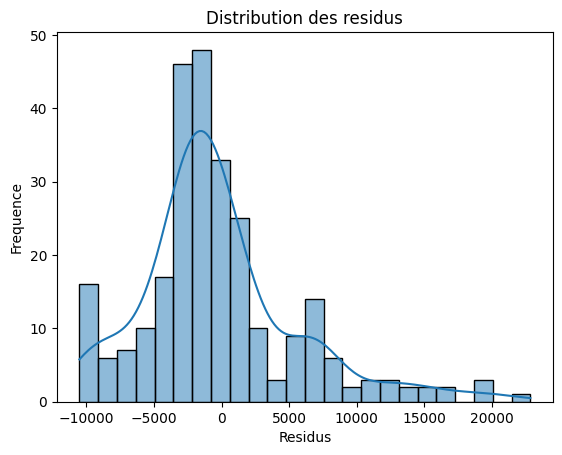

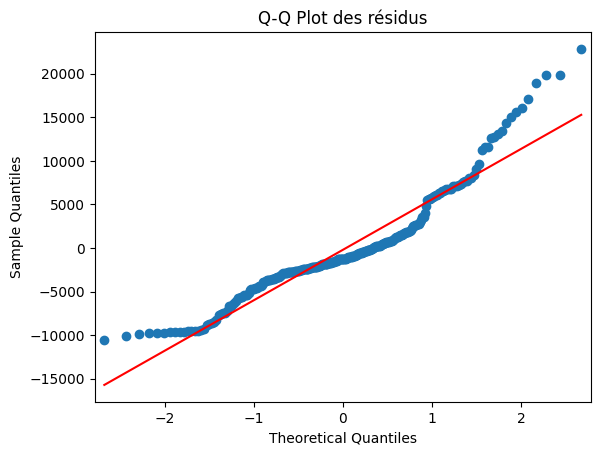

In [ ]:
# Plotting the histogram of residuals
sns.histplot(residuals_lr, kde=True)
plt.title('Distribution des residus')
plt.xlabel('Residus')
plt.ylabel('Frequence')

# Plotting the Q-Q plot of residuals
sm.qqplot(residuals_lr, line='s')
plt.title('Q-Q Plot des résidus')
plt.show()

##### **Normalité des résidus**

In [ ]:


# Perform Shapiro-Wilk test on the residuals
shapiro_test_statistic, shapiro_p_value = shapiro(residuals_lr)

print(f"Shapiro-Wilk Test Statistic: {shapiro_test_statistic:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p_value:.4f}")

# Interpret the p-value
alpha = 0.05
if shapiro_p_value < alpha:
    print("Conclusion: Les résidus ne semble pas suivre une distribution normale (rejet H0).")
else:
    print("Conclusion: Les résidus semble suivre une distribution normale (non rejet de H0).")

Shapiro-Wilk Test Statistic: 0.9139
Shapiro-Wilk p-value: 0.0000
Conclusion: Les résidus ne semble pas suivre une distribution normale (rejet H0).


##### Homoscédasticité

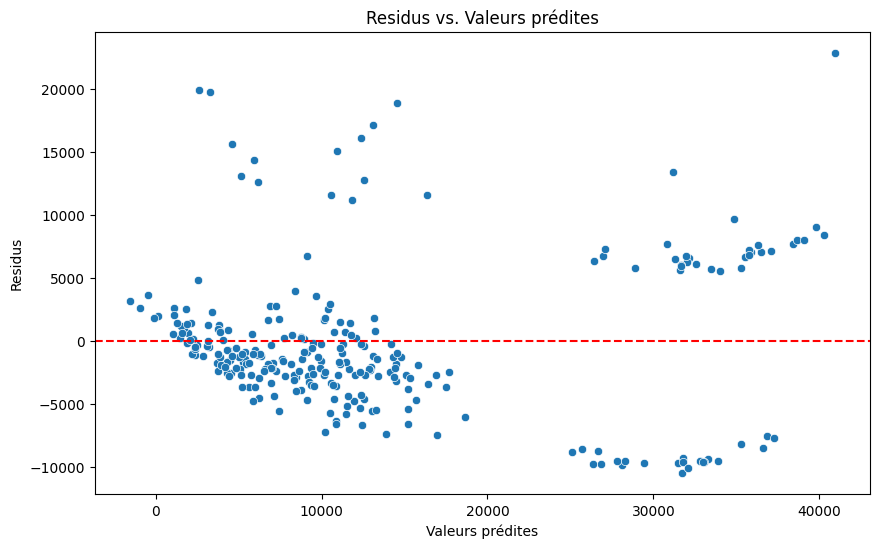

In [ ]:


# Create a scatter plot of residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lr, y=residuals_lr)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel('Valeurs prédites')
plt.ylabel('Residus')
plt.title('Residus vs. Valeurs prédites')
plt.show()

In [ ]:

# 4. Apply the preprocessor to X_test
X_test_preprocessed = preprocessor.transform(X_test)

# 5. Add a constant term to the preprocessed X_test data
X_test_preprocessed_with_const = sm.add_constant(X_test_preprocessed)

# 6. Perform the Breusch-Pagan test
bp_test = het_breuschpagan(residuals_lr, X_test_preprocessed_with_const)

# Store the results in a dictionary for easy access and printing
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_results = dict(zip(labels, bp_test))

# 7. Print the results of the Breusch-Pagan test
print("Breusch-Pagan Test Results:")
for label, value in bp_results.items():
    print(f"{label}: {value:.4f}")

# 8. Interpret the p-value (F-Test p-value)
alpha = 0.05
if bp_results['F-Test p-value'] < alpha:
    print(f"\nConclusion: F-Test p-value ({bp_results['F-Test p-value']:.4f}) < alpha ({alpha}), donc nous rejetons H0.\nIl existe suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.")
else:
    print(f"\nConclusion: F-Test p-value ({bp_results['F-Test p-value']:.4f}) >= alpha ({alpha}), donc nous rejetons H0.\nIl n'existe pas suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.")

Breusch-Pagan Test Results:
LM Statistic: 34.6614
LM-Test p-value: 0.0003
F-Statistic: 4.8092
F-Test p-value: 0.0000

Conclusion: F-Test p-value (0.0000) < alpha (0.05), donc nous rejetons H0.
Il existe suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.


##### ***Indépendance des résidus***

In [ ]:

# Perform the Durbin-Watson test on the residuals
dw_test = durbin_watson(residuals_lr)

# Print the Durbin-Watson test statistic
print(f"Durbin-Watson test statistic: {dw_test:.4f}")

# Interpret the Durbin-Watson statistic
if dw_test < 1.5 or dw_test > 2.5:
    print("Conclusion: The residuals exhibit evidence of autocorrelation (not independent).")
else:
    print("Conclusion: The residuals appear to be independent (no significant autocorrelation).")

Durbin-Watson test statistic: 2.1905
Conclusion: The residuals appear to be independent (no significant autocorrelation).


### **Optimisation**

In [ ]:
# Définir les modèles et leurs grilles de paramètres
models_to_tune = {
        'LinearRegression': (LinearRegression(), {
            'reg__fit_intercept': [True, False]
        }),
        'Lasso': (Lasso(max_iter=10000), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0]
        }),
        'Ridge': (Ridge(), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0]
        }),
        'ElasticNet': (ElasticNet(), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0],
            'reg__l1_ratio': [0.0, 0.1, 0.5, 0.9]
        }),
        'KNN': (KNeighborsRegressor(), {
            'reg__n_neighbors': [3, 5, 7, 9],
            'reg__weights': ['uniform', 'distance']
        }),
        'SVR': (SVR(), {
            'reg__C': [0.1, 1, 10, 100],
            'reg__epsilon': [0.1, 0.2, 0.5, 1.0],
            'reg__kernel': ['rbf']
        }),
        'DecisionTree': (DecisionTreeRegressor(random_state=42), {
            'reg__max_depth': [None, 5, 10, 15],
            'reg__min_samples_split': [2, 5, 10, 20]
        }),
        'RandomForest': (RandomForestRegressor(random_state=42), {
            'reg__n_estimators': [50, 100, 200, 300],
            'reg__max_depth': [None, 10, 20, 30],
            'reg__min_samples_split': [2, 5, 10, 20]
        }),
        'XGBoost': (XGBRegressor(random_state=42), {
            'reg__n_estimators': [50, 100, 200, 300],
            'reg__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'reg__max_depth': [3, 6, 9, 12]
        }),
        'GradientBoost': (GradientBoostingRegressor(random_state=42), {
            'reg__n_estimators': [50, 100, 200, 300],
            'reg__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'reg__subsample': [0.6, 0.8, 0.9, 1.0]
        })
    }


In [ ]:

def optimize_hyperparameters(X_train, y_train, preprocessor,models_to_tune, metric_score):
    """
    Optimise les  modèles implémenter précédemment.
    """
    #  Fixer le scaler gagnant dans le preprocessor
    #preprocessor.transformers[0][1].steps[0] = ('scaler', best_scaler_obj)


    tuned_results = []
    best_estimators = {}

    for name, (model, params) in models_to_tune.items():
        print(f"Optimisation de {name} en cours...")

        # Création de la pipeline
        pipe = Pipeline(steps=[('prepro', preprocessor), ('reg', model)])

        # GridSearchCV : cv=5 (K-Fold), scoring='neg_mean_absolute_error'
        grid = GridSearchCV(pipe, params, cv=5, scoring=metric_score, n_jobs=-1)
        grid.fit(X_train, y_train)

        # Stockage du meilleur estimateur
        best_estimator = grid.best_estimator_
        best_estimators[name] = best_estimator

        # Prédictions avec le meilleur estimateur
        y_train_pred = best_estimator.predict(X_train)
        y_test_pred = best_estimator.predict(X_test)

        # Calcul des métriques
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)

        res = {
            'Model': name,
            'Best_MAE_CV': -grid.best_score_,
            'Best_Params': grid.best_params_,
            'MAE_Train': mean_absolute_error(y_train, y_train_pred),
            'MAE_Test': mean_absolute_error(y_test, y_test_pred),
            'MSE_Train': mean_squared_error(y_train, y_train_pred),
            'MSE_Test': mean_squared_error(y_test, y_test_pred),
            'RMSE_Train': root_mean_squared_error(y_train, y_train_pred),
            'RMSE_Test': root_mean_squared_error(y_test, y_test_pred),
            'MAPE_Train': mean_absolute_percentage_error(y_train, y_train_pred),
            'MAPE_Test': mean_absolute_percentage_error(y_test, y_test_pred),
            'R2_Train': r2_train,
            'R2_Test': r2_test
        }
        res['Overfit_Diff'] = abs(r2_train - r2_test)
        tuned_results.append(res)

    return pd.DataFrame(tuned_results), best_estimators

In [ ]:
# Supposons que  RobustScaler était le meilleur
df_tuning, best_models_dict = optimize_hyperparameters(X_train, y_train, preprocessor, models_to_tune, 'neg_mean_absolute_error')

display(df_tuning)

Optimisation de LinearRegression en cours...
Optimisation de Lasso en cours...
Optimisation de Ridge en cours...
Optimisation de ElasticNet en cours...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.991e+10, tolerance: 1.544e+07
  model = cd_fast.enet_coordinate_descent(


Optimisation de KNN en cours...
Optimisation de SVR en cours...
Optimisation de DecisionTree en cours...
Optimisation de RandomForest en cours...
Optimisation de XGBoost en cours...
Optimisation de GradientBoost en cours...


,Model,Best_MAE_CV,Best_Params,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test,MAPE_Train,MAPE_Test,R2_Train,R2_Test,Overfit_Diff
0,LinearRegression,4245.227948,{'reg__fit_intercept': False},4208.234572,4181.194474,3.727768e+07,3.359692e+07,6105.545160,5796.284659,0.422027,0.468883,0.741726,0.783593,0.041867
1,Lasso,4245.227912,{'reg__alpha': 0.001},4208.234945,4181.195000,3.727768e+07,3.359692e+07,6105.545160,5796.284887,0.422027,0.468883,0.741726,0.783593,0.041867
2,Ridge,4245.233647,{'reg__alpha': 0.001},4208.239418,4181.200578,3.727768e+07,3.359694e+07,6105.545160,5796.286588,0.422028,0.468884,0.741726,0.783593,0.041867
3,ElasticNet,4245.570134,"{'reg__alpha': 0.001, 'reg__l1_ratio': 0.9}",4208.599889,4181.657839,3.727769e+07,3.359864e+07,6105.545515,5796.433342,0.422095,0.468976,0.741726,0.783582,0.041856
4,KNN,6635.985184,"{'reg__n_neighbors': 3, 'reg__weights': 'dista...",29.572515,6128.696730,2.442396e+05,1.072887e+08,494.205984,10358.024209,0.008472,0.625529,0.998308,0.308924,0.689384
5,SVR,6848.091298,"{'reg__C': 100, 'reg__epsilon': 0.1, 'reg__ker...",6784.376155,6660.398961,1.673230e+08,1.687572e+08,12935.340450,12990.659430,0.361803,0.360828,-0.159280,-0.087012,0.072268
6,DecisionTree,2827.654006,"{'reg__max_depth': 5, 'reg__min_samples_split'...",2336.926466,2866.786740,1.734689e+07,2.504331e+07,4164.960110,5004.328898,0.279981,0.343798,0.879814,0.838689,0.041125
7,RandomForest,2660.920349,"{'reg__max_depth': 10, 'reg__min_samples_split...",2089.490644,2531.185593,1.403621e+07,2.002133e+07,3746.493605,4474.520156,0.241979,0.306797,0.902752,0.871037,0.031715
8,XGBoost,2601.706369,"{'reg__learning_rate': 0.1, 'reg__max_depth': ...",2319.646872,2445.291083,1.746741e+07,1.801881e+07,4179.402741,4244.856472,0.289348,0.324244,0.878979,0.883936,0.004957
9,GradientBoost,2599.836421,"{'reg__learning_rate': 0.05, 'reg__n_estimator...",2296.403501,2512.702005,1.668163e+07,1.899625e+07,4084.314681,4358.468857,0.280831,0.319101,0.884423,0.877640,0.006783


In [ ]:
# 4. Affichage visuel
style_results(df_tuning)

,Model,Best_MAE_CV,Best_Params,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test,MAPE_Train,MAPE_Test,R2_Train,R2_Test,Overfit_Diff
0,LinearRegression,4245.23,{'reg__fit_intercept': True},4208.23,4181.19,37277681.70,33596915.85,6105.55,5796.28,0.42,0.47,0.74,0.78,0.04
1,Lasso,4244.92,{'reg__alpha': 1.0},4208.23,4182.01,37277716.19,33605907.52,6105.55,5797.06,0.42,0.47,0.74,0.78,0.04
2,Ridge,4245.23,{'reg__alpha': 0.001},4208.24,4181.20,37277681.70,33596939.17,6105.55,5796.29,0.42,0.47,0.74,0.78,0.04
3,ElasticNet,4245.46,"{'reg__alpha': 0.001, 'reg__l1_ratio': 0.9}",4208.52,4181.59,37277687.47,33598744.22,6105.55,5796.44,0.42,0.47,0.74,0.78,0.04
4,KNN,3324.61,"{'reg__n_neighbors': 5, 'reg__weights': 'distance'}",29.57,3304.05,244239.55,29829353.95,494.21,5461.63,0.01,0.41,1.00,0.81,0.19
5,SVR,6286.77,"{'reg__C': 100, 'reg__epsilon': 1.0, 'reg__kernel': 'rbf'}",5696.99,5772.65,113404184.86,117043829.27,10649.14,10818.68,0.41,0.43,0.21,0.25,0.03
6,DecisionTree,2826.39,"{'reg__max_depth': 5, 'reg__min_samples_split': 20}",2336.93,2866.79,17346892.72,25043307.72,4164.96,5004.33,0.28,0.34,0.88,0.84,0.04
7,RandomForest,2661.42,"{'reg__max_depth': 10, 'reg__min_samples_split': 20, 'reg__n_estimators': 50}",2087.08,2533.23,14025788.65,20029233.64,3745.10,4475.40,0.24,0.31,0.90,0.87,0.03
8,XGBoost,2601.71,"{'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 50}",2319.65,2445.29,17467407.27,18018806.47,4179.40,4244.86,0.29,0.32,0.88,0.88,0.00
9,GradientBoost,2598.19,"{'reg__learning_rate': 0.05, 'reg__n_estimators': 100, 'reg__subsample': 0.8}",2296.40,2512.70,16681626.42,18996250.78,4084.31,4358.47,0.28,0.32,0.88,0.88,0.01


### **Choix du meilleur modèle**

#### ***Infos sur le meilleur modèle***

In [ ]:
best_model_idx = df_tuning['MAE_Test'].idxmin()
best_model = df_tuning.loc[best_model_idx]
display(best_model)

,8
Model,XGBoost
Best_MAE_CV,2601.706369
Best_Params,"{'reg__learning_rate': 0.1, 'reg__max_depth': ..."
MAE_Train,2319.646872
MAE_Test,2445.291083
MSE_Train,17467407.27283
MSE_Test,18018806.469759
RMSE_Train,4179.402741
RMSE_Test,4244.856472
MAPE_Train,0.289348


In [ ]:
# Nom et paramètres du meilleur modèle
best_model_name = best_model['Model']
best_params = best_model['Best_Params']

print(f"Meilleur modèle: {best_model_name}")
print(f"Hyperparamètres optimaux: {best_params}")

Meilleur modèle: XGBoost
Hyperparamètres optimaux: {'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 50}


In [ ]:
#Pipeline du meilleur modèle
best_pipeline = best_models_dict[best_model_name]

print(f"Objet pipeline du meilleur modèle: {best_pipeline}")

Objet pipeline du meilleur modèle: Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('reg',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              c...
                              feature_types=None


#### ***Prediction***


In [ ]:
##Prediction sur les données test
y_test_pred_final = best_pipeline.predict(X_test)

In [ ]:
## Calcul
# Calcul de l'erreur absolue moyenne (Mean Absolute Error - MAE) sur l'ensemble de test
mae_test_final = mean_absolute_error(y_test, y_test_pred_final)
# Calcul de l'erreur quadratique moyenne (Mean Squared Error - MSE) sur l'ensemble de test
mse_test_final = mean_squared_error(y_test, y_test_pred_final)
# Calcul de la racine carrée de l'erreur quadratique moyenne (Root Mean Squared Error - RMSE) sur l'ensemble de test
rmse_test_final = root_mean_squared_error(y_test, y_test_pred_final)
# Calcul de l'erreur absolue moyenne en pourcentage (Mean Absolute Percentage Error - MAPE) sur l'ensemble de test
mape_test_final = mean_absolute_percentage_error(y_test, y_test_pred_final)
# Calcul du coefficient de détermination (R2 score) sur l'ensemble de test
r2_test_final = r2_score(y_test, y_test_pred_final)


print("Metrique sur les prédictions")
print(f"MAE: {mae_test_final:.2f}")
print(f"MSE: {mse_test_final:.2f}")
print(f"RMSE: {rmse_test_final:.2f}")
print(f"MAPE: {mape_test_final:.2f}")
print(f"R2: {r2_test_final:.2f}")

Metrique sur les prédictions
MAE: 2533.23
MSE: 20029233.64
RMSE: 4475.40
MAPE: 0.31
R2: 0.87


#### ***Simulation***

In [ ]:
# Création d'une nouvelle instance de données sous forme de DataFrame pour la simulation
# Chaque clé représente un nom de colonne et la valeur est une liste contenant la donnée correspondante
new_data_instance = pd.DataFrame({
    'age': [31, 60],         # Âge de la personne
    'sex': ['male','male'],       # Sexe de la personne
    'bmi': [25.0, 20.9],         # Indice de masse corporelle (IMC)
    'children': [1,3],       # Nombre d'enfants
    'smoker': ['yes','no'],      # Indicateur si la personne est fumeuse ou non
    'region': ['southwest','northeast'] # Région d'habitation de la personne
})

# Utilisation du pipeline du meilleur modèle (best_pipeline) pour prédire les charges
# pour la nouvelle instance de données. La méthode .predict() retourne un tableau.
predicted_charge = best_pipeline.predict(new_data_instance)

# Affichage de la prédiction des charges, formatée à deux décimales
# Nous accédons au premier élément du tableau 'predicted_charge' car la prédiction est pour une seule instance.
print(f"Prediction de charges pour la nouvelle donnée: {predicted_charge}")

Prediction de charges pour la nouvelle donnée: [18724.24  15159.536]


#### ***Importance relative des variables***

In [ ]:

# Get the feature importances from the regressor in the pipeline
regressor = best_pipeline.named_steps['reg']
feature_importances = regressor.feature_importances_

# Get feature names after preprocessing from the fitted ColumnTransformer
fitted_preprocessor = best_pipeline.named_steps['prepro']
all_feature_names = fitted_preprocessor.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})


In [ ]:
# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

display(feature_importance_df)

,Feature,Importance
5,cat__smoker_no,0.833729
1,num__bmi,0.095699
0,num__age,0.042208
2,num__children,0.008373
7,cat__region_northeast,0.005681
10,cat__region_southwest,0.005224
8,cat__region_northwest,0.003802
9,cat__region_southeast,0.002758
3,cat__sex_female,0.002527
6,cat__smoker_yes,0.000000


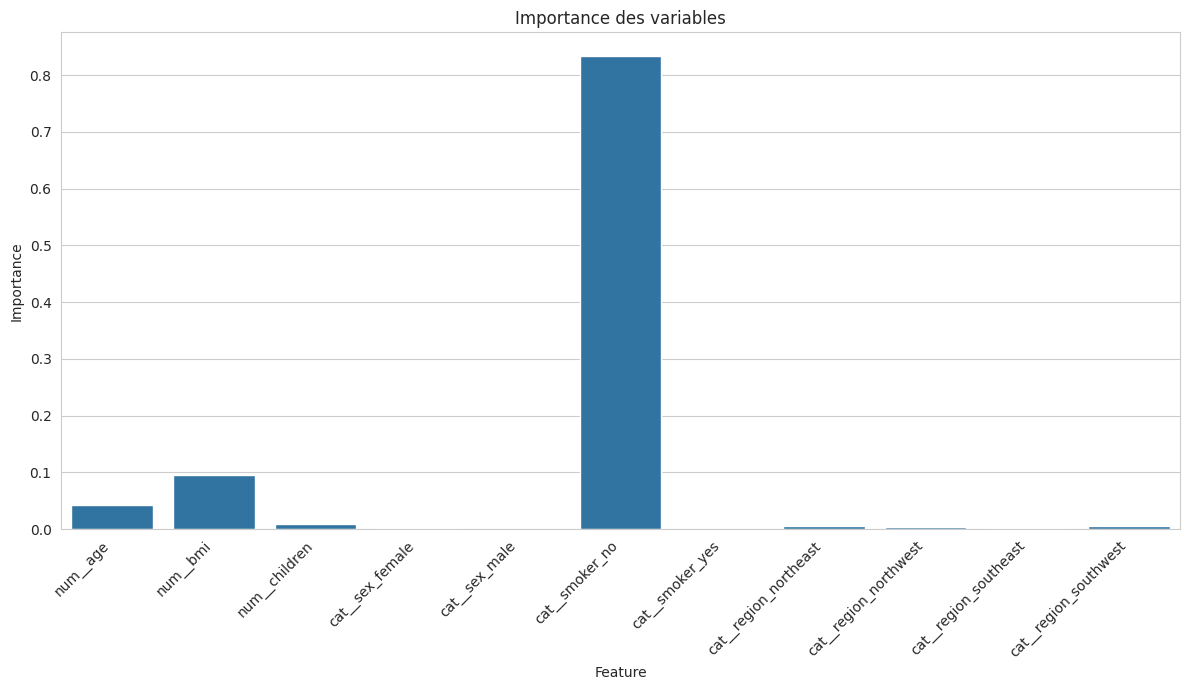

In [ ]:
# Plot feature importances
plt.figure(figsize=(12, 7)) # Increased figure size for better vertical display
sns.barplot(x='Feature', y='Importance', data=feature_importance_df)
plt.title('Importance des variables')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### ***Sauvegarde de la pipeline***

In [ ]:


# Choose a relevant file name
model_filename = 'best_gradient_boost_model.joblib'

# Save the best_pipeline
joblib.dump(best_pipeline, model_filename)

print(f"Le meilleur modèle a été sauvegardé sous le nom: {model_filename}")

Le meilleur modèle a été sauvegardé sous le nom: best_gradient_boost_model.joblib


### **Utilisation de la sauvegarde**

In [ ]:

# Définit le nom du fichier où le meilleur modèle a été sauvegardé précédemment
model_filename = 'best_gradient_boost_model.joblib'

# Charge le modèle (pipeline complet) depuis le fichier spécifié en utilisant joblib.load()
loaded_pipeline = joblib.load(model_filename)
# Affiche un message confirmant que le modèle a été chargé avec succès
print(f"Le modèle a été chargé depuis {model_filename}")

# Crée un nouveau DataFrame pour une instance de données 'inconnue' sur laquelle nous voulons faire une prédiction.
# Il est essentiel que les noms et l'ordre des colonnes, ainsi que leurs types de données, correspondent à ceux utilisés lors de l'entraînement du modèle.
new_unseen_data = pd.DataFrame({
    'age': [40],         # Âge de la personne (valeur numérique)
    'sex': ['female'],     # Sexe de la personne (catégorie)
    'bmi': [28.5],         # Indice de masse corporelle (IMC) (valeur numérique)
    'children': [2],       # Nombre d'enfants (valeur numérique)
    'smoker': ['no'],      # Indicateur si la personne est fumeuse ou non (catégorie)
    'region': ['northwest'] # Région d'habitation de la personne (catégorie)
})

# Utilise le pipeline chargé ('loaded_pipeline') pour prédire les charges pour la nouvelle instance de données.
# La méthode .predict() applique automatiquement toutes les étapes de prétraitement (scaling, encodage) avant la prédiction par le modèle sous-jacent.
predicted_charge_loaded_model = loaded_pipeline.predict(new_unseen_data)

# Affiche le résultat de la prédiction.
# predicted_charge_loaded_model est un tableau NumPy, nous accédons au premier (et unique) élément [0]
# et le formatons pour afficher deux chiffres après la virgule pour plus de clarté.
print(f"Prédiction des charges pour la nouvelle donnée en utilisant le modèle chargé : {predicted_charge_loaded_model[0]:.2f}")

Le modèle a été chargé depuis best_gradient_boost_model.joblib
Prédiction des charges pour la nouvelle donnée en utilisant le modèle chargé : 7937.28
